In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises_fisher
from matplotlib.colors import Normalize

In [2]:
#color scales: Blue to pink
# Blue 161,219,234
# Himmelblå 147,185,206
# Lyseblå 137,186,227
# Isblå 135,179,208
# Kornblå 163,175,209
# Blågrå 120,155,189
# Blågrå 133,151,187
# Lavendel 163,153,187
# Lavendel 172,152,187
# Lavendel 177,158,186
# Lavendel 185,180,210
# Pink lavendel 210,195,214
# Lysest lavendel 213,200,210

colors = [
    "#6ad6f2",  # Blue
    "#69b1d8",  # Himmelblå
    "#50a4da",  # Isblå
    "#44a1ee",  # Lyseblå
    "#5e80c4",  # Blågrå
    "#859bdb",  # Kornblå
    "#a882c4",  # Lavendel
    "#b28ec3",  # Lavendel
    "#d9bde1",  # Pink lavendel
    "#e0c7da",  # Lysest lavendel
]

blue_pink = LinearSegmentedColormap.from_list("blue_pink", colors, N=256)

In [3]:
theta = np.linspace(0, 2 * np.pi, 100)
phi = np.linspace(0, np.pi, 50)
theta, phi = np.meshgrid(theta, phi)
r = 1
# Convert to Cartesian coordinates
x = r * np.sin(phi) * np.cos(theta)
y = r * np.sin(phi) * np.sin(theta)
z = r * np.cos(phi)
print(f"Shape of x, y, z: {x.shape}")
print(f"Min and max values - x: ({x.min():.2f}, {x.max():.2f}), y: ({y.min():.2f}, {y.max():.2f}), z: ({z.min():.2f}, {z.max():.2f})")

Shape of x, y, z: (50, 100)
Min and max values - x: (-1.00, 1.00), y: (-1.00, 1.00), z: (-1.00, 1.00)


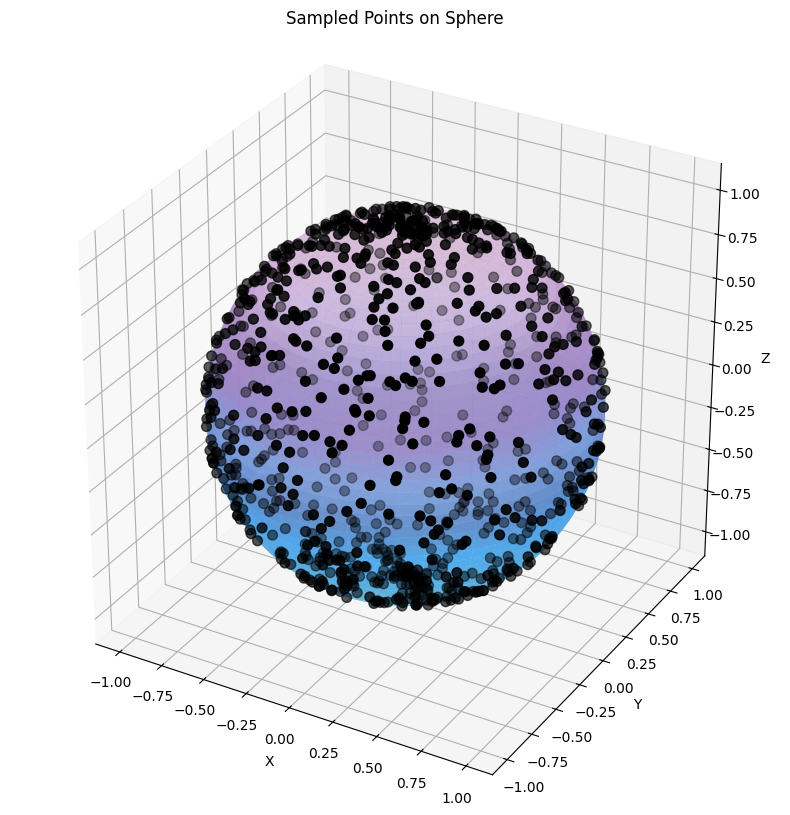

In [4]:
# sample points on the sphere
num_points = 1000
phi_points = np.random.uniform(0, np.pi, num_points)
theta_points = np.random.uniform(0, 2 * np.pi, num_points)
x_points = (r*1.002) * np.sin(phi_points) * np.cos(theta_points) 
y_points = (r*1.002) * np.sin(phi_points) * np.sin(theta_points)
z_points = (r*1.002) * np.cos(phi_points)
# plot the sampled points on the spere
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, cmap=blue_pink, alpha=0.8)
ax.scatter(x_points, y_points, z_points, color='black', s=50)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Sampled Points on Sphere')
ax.set_box_aspect((1, 1, 1))
plt.show()

#### von mises fisher distribution.

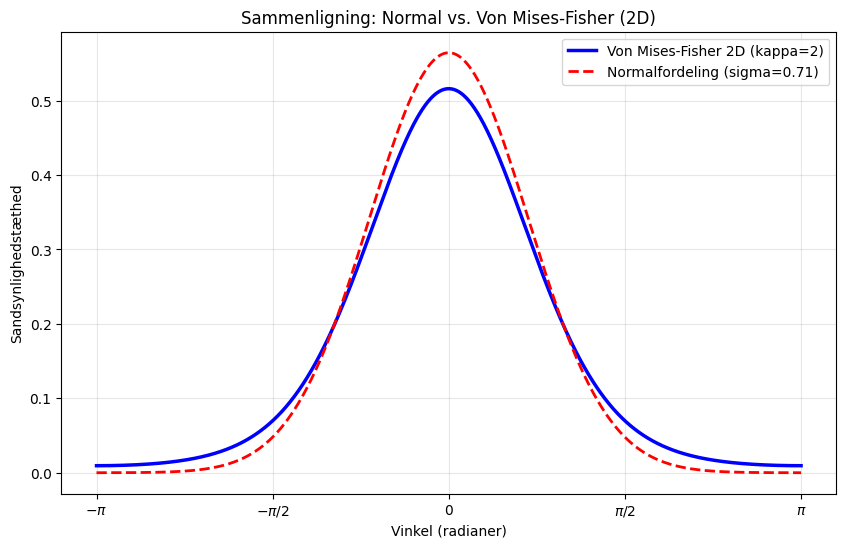

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises, norm

mu = 0                # Middelretning (0 er toppen af cirklen)
kappa = 2             # Koncentration for vMF
sigma = np.sqrt(1/kappa) # Tilsvarende standardafvigelse for Normalfordelingen [3, 4]

# x-aksen fra -pi til pi (svarende til en hel cirkel)
x = np.linspace(-np.pi, np.pi, 1000)

# Beregn PDF (Probability Density Function)
vmf_pdf = vonmises.pdf(x, kappa, loc=mu)  # i 2d, blot von Mises.
norm_pdf = norm.pdf(x, loc=mu, scale=sigma)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, vmf_pdf, label=f'Von Mises-Fisher 2D (kappa={kappa})', lw=2.5, color='blue')
plt.plot(x, norm_pdf, label=f'Normalfordeling (sigma={sigma:.2f})', lw=2, linestyle='--', color='red')

plt.title('Sammenligning: Normal vs. Von Mises-Fisher (2D)')
plt.xlabel('Vinkel (radianer)')
plt.ylabel('Sandsynlighedstæthed')
plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], [r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

on spheres.

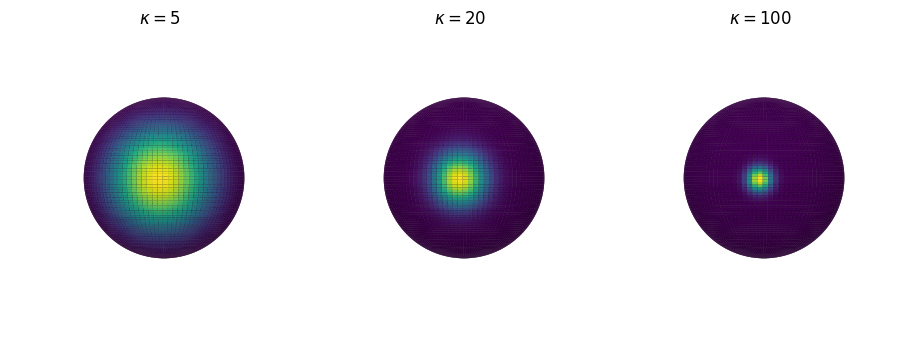

In [6]:
# Visualization of the probability density variating the shape parameter kappa.
n_grid = 100
u = np.linspace(0, np.pi, n_grid)
v = np.linspace(0, 2 * np.pi, n_grid)
u_grid, v_grid = np.meshgrid(u, v)
vertices = np.stack([np.cos(v_grid) * np.sin(u_grid),
                     np.sin(v_grid) * np.sin(u_grid),
                     np.cos(u_grid)],
                    axis=2)
x = np.outer(np.cos(v), np.sin(u))
y = np.outer(np.sin(v), np.sin(u))
z = np.outer(np.ones_like(u), np.cos(u))
def plot_vmf_density(ax, x, y, z, vertices, mu, kappa):
    vmf = vonmises_fisher(mu, kappa)
    pdf_values = vmf.pdf(vertices)
    pdfnorm = Normalize(vmin=pdf_values.min(), vmax=pdf_values.max())
    ax.plot_surface(x, y, z, rstride=1, cstride=1,
                    facecolors=plt.cm.viridis(pdfnorm(pdf_values)),
                    linewidth=0)
    ax.set_aspect('equal')
    ax.view_init(azim=-130, elev=0)
    ax.axis('off')
    ax.set_title(rf"$\kappa={kappa}$")
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(9, 4),
                         subplot_kw={"projection": "3d"})
left, middle, right = axes
mu = np.array([-np.sqrt(0.5), -np.sqrt(0.5), 0])
plot_vmf_density(left, x, y, z, vertices, mu, 5)
plot_vmf_density(middle, x, y, z, vertices, mu, 20)
plot_vmf_density(right, x, y, z, vertices, mu, 100)
plt.subplots_adjust(top=1, bottom=0.0, left=0.0, right=1.0, wspace=0.)
plt.show()

In [7]:
# draw samples from von mises fisher distribution
rng = np.random.default_rng()
mu = np.array([0, 0, 1])
samples = vonmises_fisher(mu, 20).rvs(5, random_state=rng)
samples

array([[ 0.32350245, -0.25160324,  0.91216335],
       [ 0.1508487 , -0.04591473,  0.98749   ],
       [ 0.23649053, -0.31049128,  0.92068854],
       [-0.28092037, -0.0801026 ,  0.95638241],
       [ 0.08595942, -0.03829621,  0.99556234]])

In [8]:
# samples should be unit vectors on the sphere.
# Check the norms of the samples
np.linalg.norm(samples, axis=1)

array([1., 1., 1., 1., 1.])

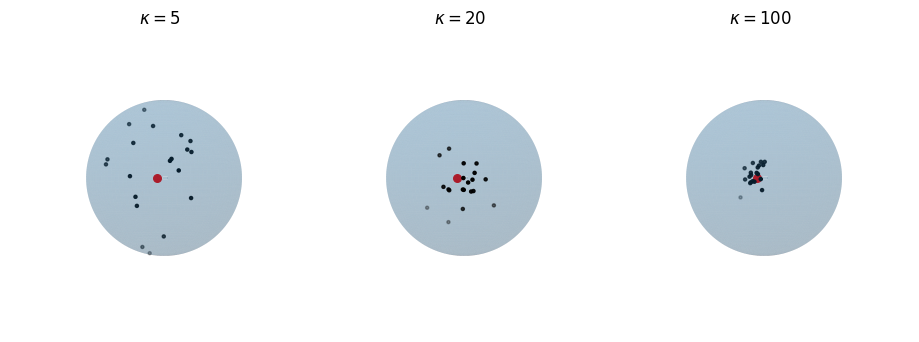

In [9]:
# plot 20 observations drawn from the vMF distribution for variating kappa. The red is the mean direction mu.
def plot_vmf_samples(ax, x, y, z, mu, kappa):
    vmf = vonmises_fisher(mu, kappa)
    samples = vmf.rvs(20)
    ax.plot_surface(x, y, z, rstride=1, cstride=1, linewidth=0,
                    alpha=0.2)
    ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2], c='k', s=5)
    ax.scatter(mu[0], mu[1], mu[2], c='r', s=30)
    ax.set_aspect('equal')
    ax.view_init(azim=-130, elev=0)
    ax.axis('off')
    ax.set_title(rf"$\kappa={kappa}$")
mu = np.array([-np.sqrt(0.5), -np.sqrt(0.5), 0])
fig, axes = plt.subplots(nrows=1, ncols=3,
                         subplot_kw={"projection": "3d"},
                         figsize=(9, 4))
left, middle, right = axes
plot_vmf_samples(left, x, y, z, mu, 5)
plot_vmf_samples(middle, x, y, z, mu, 20)
plot_vmf_samples(right, x, y, z, mu, 100)
plt.subplots_adjust(top=1, bottom=0.0, left=0.0,
                    right=1.0, wspace=0.)
plt.show() 

#### Align VMF on 2-sphere

Distribution, sample, align

In [10]:
class S2Distribution:
    def sample(self, n, rng=None):
        raise NotImplementedError

    def pdf(self, x):
        raise NotImplementedError

In [11]:
class VMF:
    def __init__(self, mu, kappa):
        self.mu = mu / np.linalg.norm(mu) # norm so length 1
        self.kappa = kappa
        self._dist = vonmises_fisher(self.mu, self.kappa)

    def sample(self, n, rng=None):
        return self._dist.rvs(n, random_state=rng)

    def pdf(self, x):
        return self._dist.pdf(x)

In [12]:
def create_sphere(res=100):
    u = np.linspace(0, np.pi, res)
    v = np.linspace(0, 2*np.pi, res)
    u, v = np.meshgrid(u, v)
    x = np.cos(v)*np.sin(u)
    y = np.sin(v)*np.sin(u)
    z = np.cos(u)
    return x, y, z

def plot_samples(ax, sphere, samples, mu=None, title=""):
    x, y, z = sphere
    ax.plot_surface(x, y, z, alpha=0.15, linewidth=0)
    ax.scatter(samples[:,0], samples[:,1], samples[:,2], s=10)
    if mu is not None:
        ax.scatter(*mu, c='r', s=40)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title)

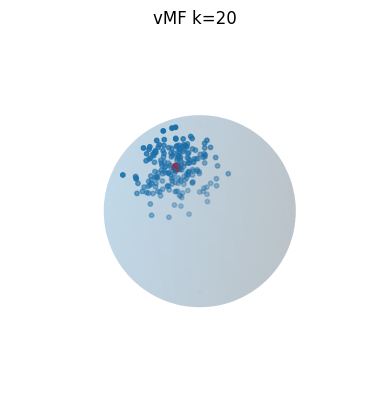

In [13]:
# Ground truth sphere with vmf distribution 
mu = np.array([-np.sqrt(0.5), np.sqrt(0.5), 0])

rng = np.random.default_rng(42)
sphere = create_sphere()

dist_GT = VMF(mu, kappa=20)
samples_GT = dist_GT.sample(200, rng=rng)

fig, ax = plt.subplots(subplot_kw={"projection":"3d"})
plot_samples(ax, sphere, samples_GT, mu=mu, title="vMF k=20")

In [14]:
# sample once, apply known rotation
# 1. Ground truth distribution
mu = np.array([-np.sqrt(0.5), np.sqrt(0.5), 0])
dist = VMF(mu, kappa=20)

rng = np.random.default_rng(42)
samples_GT = dist.sample(200, rng=rng)

# 2. Create true rotation
def random_rotation(rng):
    A = rng.normal(size=(3,3))
    Q, R = np.linalg.qr(A)
    if np.linalg.det(Q) < 0:
        Q[:,0] *= -1
    return Q

R_true = random_rotation(rng)
mu_target = R_true @ mu

# 3. Apply rotation to create paired target
samples_e = samples_GT @ R_true.T

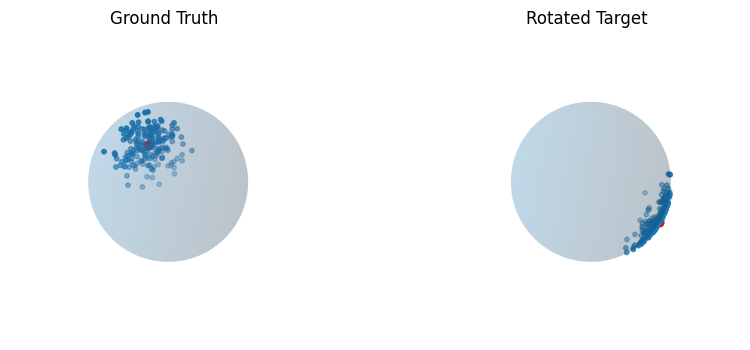

In [15]:
fig = plt.figure(figsize=(10,4))

ax1 = fig.add_subplot(121, projection="3d")
plot_samples(ax1, sphere, samples_GT, mu=mu, title="Ground Truth")

ax2 = fig.add_subplot(122, projection="3d")
plot_samples(ax2, sphere, samples_e, mu=mu_target, title="Rotated Target")

plt.show()

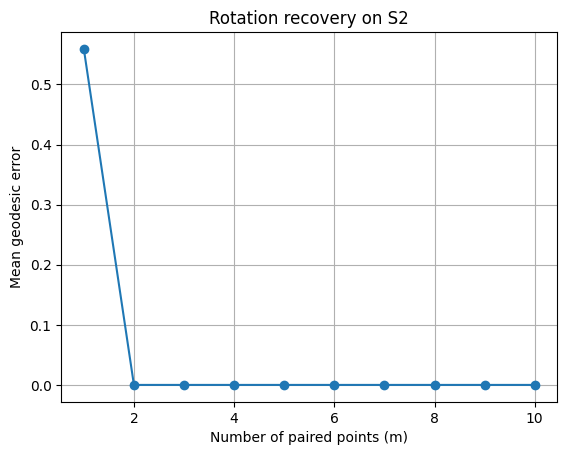

In [16]:
def estimate_rotation(X, Y):
    H = X.T @ Y
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1,:] *= -1
        R = Vt.T @ U.T
    return R

errors = []

for m in range(1, 11):
    R_hat = estimate_rotation(samples_GT[:m], samples_e[:m])
    aligned = samples_GT @ R_hat.T
    geodesic = np.arccos(np.clip(
        np.sum(aligned * samples_e, axis=1), -1, 1
    ))
    errors.append(geodesic.mean())

plt.figure()
plt.plot(range(1,11), errors, marker='o')
plt.xlabel("Number of paired points (m)")
plt.ylabel("Mean geodesic error")
plt.title("Rotation recovery on S2")
plt.grid(True)
plt.show()

In [17]:
# check:
R_hat_full = estimate_rotation(samples_GT, samples_e)
print("Rotation error:",
      np.linalg.norm(R_hat_full - R_true))

Rotation error: 1.5171919685826261e-15


edge case, 2 points on the same great circle (ie when rotation is not gauranteed to give an alignment)

In [18]:

def create_sphere(res=80):
    u = np.linspace(0, np.pi, res)
    v = np.linspace(0, 2*np.pi, res)
    u, v = np.meshgrid(u, v)
    x = np.cos(v)*np.sin(u)
    y = np.sin(v)*np.sin(u)
    z = np.cos(u)
    return x, y, z

def estimate_rotation(X, Y):
    H = X.T @ Y
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T
    return R

def setup_axes(ax, sphere, title=""):
    xs, ys, zs = sphere
    ax.plot_wireframe(xs, ys, zs, rstride=3, cstride=3, alpha=0.15)
    ax.set_xlim([-1,1]); ax.set_ylim([-1,1]); ax.set_zlim([-1,1])
    ax.set_box_aspect([1,1,1])
    ax.axis("off")
    ax.set_title(title)
    ax.view_init(elev=20, azim=60)

# Points :
x3 = np.array([0., 0., 1.])   # north pole (mu_GT)
x1 = np.array([1., 0., 0.])   # equator (right)
x2 = np.array([-1., 0., 0.])  # equator (left)
X3 = np.vstack([x1, x2, x3])

R_flip = np.array([[1,0,0],[0,-1,0],[0,0,-1]])
Y3 = X3 @ R_flip.T

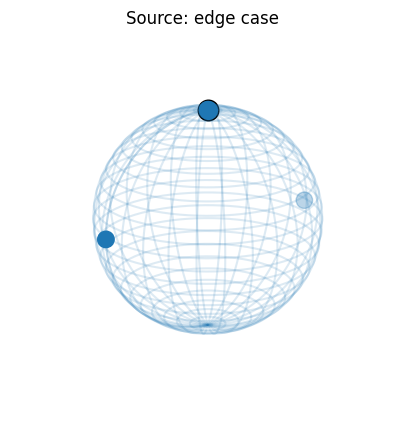

In [19]:
sphere = create_sphere()

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection="3d")
setup_axes(ax, sphere, "Source: edge case")

ax.scatter(X3[:,0], X3[:,1], X3[:,2], s=140, c=["tab:blue","tab:blue","tab:blue"])
ax.scatter(x3[0], x3[1], x3[2], s=220, c="tab:blue", edgecolors="k")
plt.show()

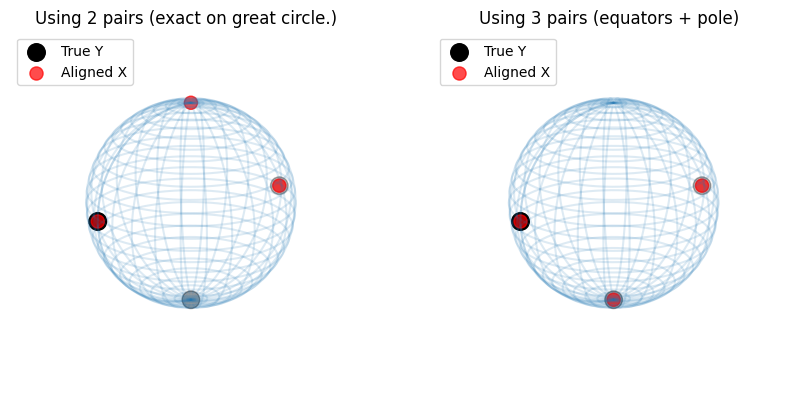

In [20]:
R_hat_2 = estimate_rotation(X3[:2], Y3[:2])   # only equator pairs
R_hat_3 = estimate_rotation(X3, Y3)           # equator + pole

A2 = X3 @ R_hat_2.T
A3 = X3 @ R_hat_3.T

fig = plt.figure(figsize=(10,5))

ax1 = fig.add_subplot(121, projection="3d")
setup_axes(ax1, sphere, "Using 2 pairs (exact on great circle.)")
ax1.scatter(Y3[:,0], Y3[:,1], Y3[:,2], s=160, c="k", label="True Y")
ax1.scatter(A2[:,0], A2[:,1], A2[:,2], s=90, c="r", alpha=0.7, label="Aligned X")
ax1.legend(loc="upper left")
# with only those two, the rotation is underdetermined.

ax2 = fig.add_subplot(122, projection="3d")
setup_axes(ax2, sphere, "Using 3 pairs (equators + pole)")
ax2.scatter(Y3[:,0], Y3[:,1], Y3[:,2], s=160, c="k", label="True Y")
ax2.scatter(A3[:,0], A3[:,1], A3[:,2], s=90, c="r", alpha=0.7, label="Aligned X")
ax2.legend(loc="upper left")

plt.show()

#### Spherical Ellipse: 

Elliptical distributions on spheres...

non-symmetric spherical distribution, so alignment should be easier.

In [21]:
class ProjectedNormal:
    def __init__(self, m, Sigma):
        self.m = m
        self.Sigma = Sigma
        self.L = np.linalg.cholesky(Sigma)

    def sample(self, n, rng):
        z = self.m + rng.normal(size=(n,3)) @ self.L.T
        x = z / np.linalg.norm(z, axis=1, keepdims=True)
        return x
    
def spherical_density_on_grid(m, Sigma, sphere):
    xs, ys, zs = sphere
    pts = np.stack([xs, ys, zs], axis=-1)
    Sigma_inv = np.linalg.inv(Sigma)

    diff = pts - m/np.linalg.norm(m)
    quad = np.einsum('...i,ij,...j->...', diff, Sigma_inv, diff)
    density = np.exp(-0.5 * quad)
    return density

def spherical_density_param(m, Sigma, res=200):
    theta = np.linspace(0, np.pi, res)
    phi = np.linspace(0, 2*np.pi, res)
    Theta, Phi = np.meshgrid(theta, phi)

    X = np.stack([
        np.cos(Phi)*np.sin(Theta),
        np.sin(Phi)*np.sin(Theta),
        np.cos(Theta)
    ], axis=-1)

    Sigma_inv = np.linalg.inv(Sigma)
    m_unit = m / np.linalg.norm(m)

    diff = X - m_unit
    quad = np.einsum('...i,ij,...j->...', diff, Sigma_inv, diff)
    density = np.exp(-0.5 * quad)

    return Theta, Phi, X, density

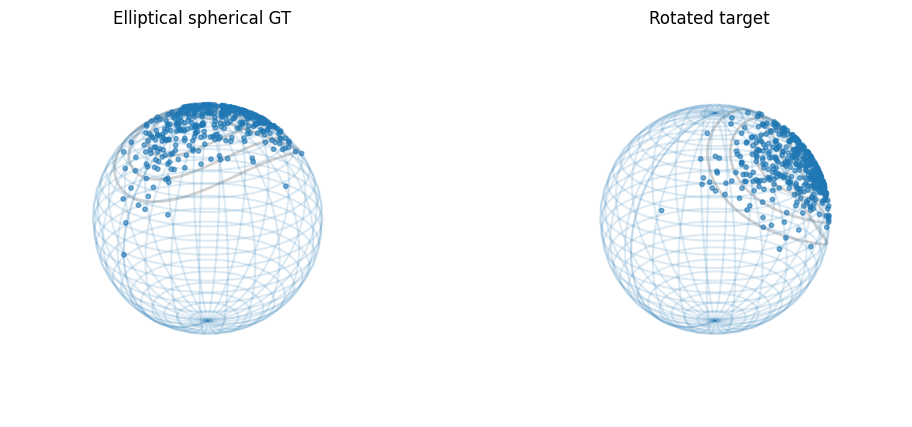

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Utilities
# -------------------------------------------------

def create_sphere(res=80):
    u = np.linspace(0, np.pi, res)
    v = np.linspace(0, 2*np.pi, res)
    u, v = np.meshgrid(u, v)
    x = np.cos(v)*np.sin(u)
    y = np.sin(v)*np.sin(u)
    z = np.cos(u)
    return x, y, z

def estimate_rotation(X, Y):
    H = X.T @ Y
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1,:] *= -1
        R = Vt.T @ U.T
    return R

def setup_axes(ax, sphere, title=""):
    xs, ys, zs = sphere
    ax.plot_wireframe(xs, ys, zs, rstride=3, cstride=3, alpha=0.15)
    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    ax.set_box_aspect([1,1,1])
    ax.axis("off")
    ax.set_title(title)
    ax.view_init(elev=25, azim=45)

# -------------------------------------------------
# Elliptical spherical model
# -------------------------------------------------

class ProjectedNormal:
    def __init__(self, m, Sigma):
        self.m = m
        self.Sigma = Sigma
        self.L = np.linalg.cholesky(Sigma)

    def sample(self, n, rng):
        z = self.m + rng.normal(size=(n,3)) @ self.L.T
        x = z / np.linalg.norm(z, axis=1, keepdims=True)
        return x

# -------------------------------------------------
# Proper spherical density contours
# -------------------------------------------------

def spherical_density_param(m, Sigma, res=200):
    theta = np.linspace(0, np.pi, res)
    phi = np.linspace(0, 2*np.pi, res)
    Theta, Phi = np.meshgrid(theta, phi)

    X = np.stack([
        np.cos(Phi)*np.sin(Theta),
        np.sin(Phi)*np.sin(Theta),
        np.cos(Theta)
    ], axis=-1)

    Sigma_inv = np.linalg.inv(Sigma)
    m_unit = m / np.linalg.norm(m)

    diff = X - m_unit
    quad = np.einsum('...i,ij,...j->...', diff, Sigma_inv, diff)
    density = np.exp(-0.5 * quad)

    return Theta, Phi, density

def add_density_contours_s2(ax3d, m, Sigma, levels=(0.4, 0.6, 0.8), res=300,
                            color="gray", alpha=0.35, linewidth=2):
    """
    Draw spherical density level-set curves on S^2 by:
    (1) computing density on (theta, phi) grid,
    (2) extracting 2D contours on a hidden 2D axis,
    (3) mapping contour segments back to 3D and plotting on ax3d.
    """
    Theta, Phi, density = spherical_density_param(m, Sigma, res=res)
    density = density / density.max()

    # Hidden 2D contour extraction
    fig2, ax2d = plt.subplots()
    CS = ax2d.contour(Theta, Phi, density, levels=list(levels))  # must be increasing
    plt.close(fig2)

    # Map contours back to S^2
    for lvl_segs in CS.allsegs:
        for seg in lvl_segs:
            theta = seg[:, 0]
            phi = seg[:, 1]
            x = np.cos(phi) * np.sin(theta)
            y = np.sin(phi) * np.sin(theta)
            z = np.cos(theta)
            ax3d.plot(x, y, z, color=color, alpha=alpha, linewidth=linewidth)

# -------------------------------------------------
# Generate elliptical spherical data
# -------------------------------------------------

rng = np.random.default_rng(0)

m = np.array([0, 0, 2.0])              # bias toward north
Sigma = np.diag([1.5, 0.3, 0.2])       # anisotropy

dist = ProjectedNormal(m, Sigma)
X = dist.sample(400, rng)

# True rotation
A = rng.normal(size=(3,3))
Q, _ = np.linalg.qr(A)
if np.linalg.det(Q) < 0:
    Q[:,0] *= -1
R_true = Q

Y = X @ R_true.T

# --- Force edge-case correspondences for the first 3 pairs ---
# Great circle = equator (z=0)
X[0] = np.array([ 1., 0., 0.])
X[1] = np.array([-1., 0., 0.])

# Third point off the great circle (breaks ambiguity)
X[2] = np.array([0., 0., 1.])

# Recompute Y for those edited points using the TRUE rotation
Y[0:3] = X[0:3] @ R_true.T


# Recover rotation
R_hat = estimate_rotation(X, Y)
aligned = X @ R_hat.T

# -------------------------------------------------
# Plot GT + rotated target with density contours
# -------------------------------------------------

sphere = create_sphere()
fig = plt.figure(figsize=(12,5))

# Left
ax1 = fig.add_subplot(121, projection="3d")
setup_axes(ax1, sphere, "Elliptical spherical GT")
ax1.scatter(X[:,0], X[:,1], X[:,2], s=10, alpha=0.6)
add_density_contours_s2(ax1, m, Sigma, levels=(0.4, 0.6, 0.8), color="gray", alpha=0.35)

# Right
ax2 = fig.add_subplot(122, projection="3d")
setup_axes(ax2, sphere, "Rotated target")
ax2.scatter(Y[:,0], Y[:,1], Y[:,2], s=10, alpha=0.6)

# rotate parameters for target (since Y = X @ R_true.T)
m_t = R_true @ m
Sigma_t = R_true @ Sigma @ R_true.T
add_density_contours_s2(ax2, m_t, Sigma_t, levels=(0.4, 0.6, 0.8), color="gray", alpha=0.35)

plt.show()

Mean geodesic error (1 pair): 1.5894594123122396


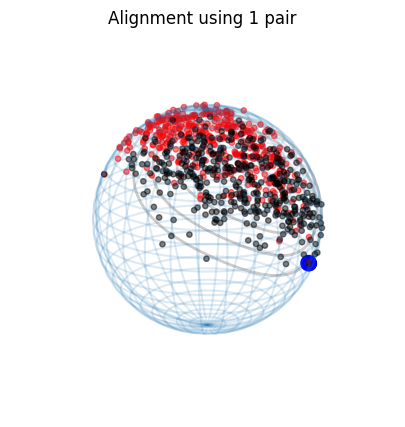

In [23]:
# now align
# -------------------------------------------------
# Align using ONE paired sample
# -------------------------------------------------

# choose one pair
x_pair = X[0:1]      # shape (1,3)
y_pair = Y[0:1]

# estimate rotation from that one pair
R_one = estimate_rotation(x_pair, y_pair)

# align entire source cloud
X_aligned_one = X @ R_one.T

# compute mean geodesic error
geodesic_one = np.arccos(np.clip(
    np.sum(X_aligned_one * Y, axis=1), -1, 1
))
print("Mean geodesic error (1 pair):", geodesic_one.mean())

# -------------------------------------------------
# Plot alignment from ONE pair
# -------------------------------------------------

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection="3d")
setup_axes(ax, sphere, "Alignment using 1 pair")

# target
ax.scatter(Y[:,0], Y[:,1], Y[:,2],
           s=15, alpha=0.5, color="black")

# aligned source
ax.scatter(X_aligned_one[:,0],
           X_aligned_one[:,1],
           X_aligned_one[:,2],
           s=15, alpha=0.5, color="red")

# add density contours of target
m_t = R_true @ m
Sigma_t = R_true @ Sigma @ R_true.T
add_density_contours_s2(ax, m_t, Sigma_t,
                        levels=(0.4,0.6,0.8),
                        color="gray", alpha=0.4)

# highlight paired point clearly
ax.scatter(Y[0,0], Y[0,1], Y[0,2],
           s=100, color="blue", edgecolors="black")

ax.scatter(X_aligned_one[0,0],
           X_aligned_one[0,1],
           X_aligned_one[0,2],
           s=100, facecolors="none",
           edgecolors="blue", linewidth=2)
ax.view_init(elev=20, azim=100)

plt.show()

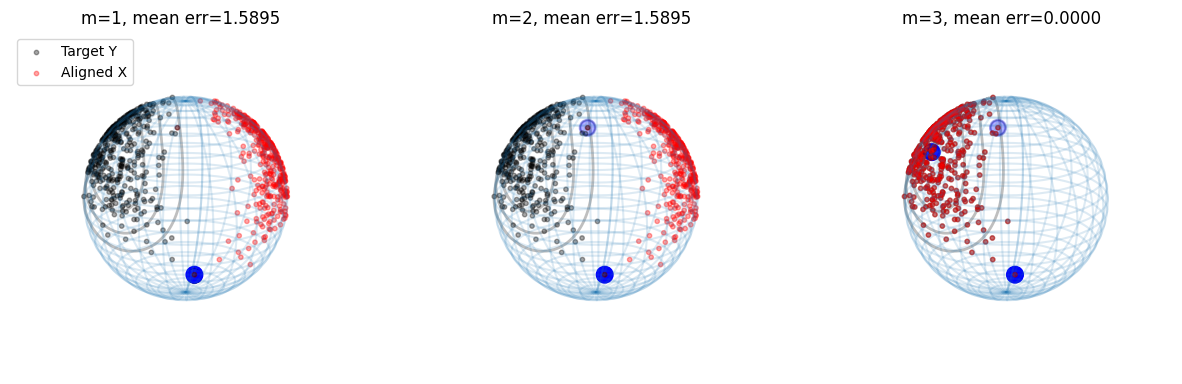

In [25]:
# how many pairs are needed for elliptical spherical alignment

# --------------------------------------------
# Helper: align using first m pairs
# --------------------------------------------
def align_with_m_pairs(X, Y, m):
    R_hat = estimate_rotation(X[:m], Y[:m])
    X_aligned = X @ R_hat.T
    geodesic = np.arccos(np.clip(np.sum(X_aligned * Y, axis=1), -1, 1))
    return R_hat, X_aligned, geodesic.mean()

# Target density parameters (for contours)
m_t = R_true @ m
Sigma_t = R_true @ Sigma @ R_true.T

# --------------------------------------------
# Plot m = 1, 2, 3 side-by-side
# --------------------------------------------
fig = plt.figure(figsize=(15,5))

for j, m_pairs in enumerate([1, 2, 3], start=1):
    _, X_aligned, err = align_with_m_pairs(X, Y, m_pairs)

    ax = fig.add_subplot(1, 3, j, projection="3d")
    setup_axes(ax, sphere, f"m={m_pairs}, mean err={err:.4f}")

    # target (black) + aligned (red)
    ax.scatter(Y[:,0], Y[:,1], Y[:,2], s=10, alpha=0.35, color="black", label="Target Y")
    ax.scatter(X_aligned[:,0], X_aligned[:,1], X_aligned[:,2], s=10, alpha=0.35, color="red", label="Aligned X")

    # target contours only
    add_density_contours_s2(ax, m_t, Sigma_t, levels=(0.4,0.6,0.8), color="gray", alpha=0.5, linewidth=2)

    # highlight the m paired points
    ax.scatter(Y[:m_pairs,0], Y[:m_pairs,1], Y[:m_pairs,2], s=120, color="blue", edgecolors="black")
    ax.scatter(X_aligned[:m_pairs,0], X_aligned[:m_pairs,1], X_aligned[:m_pairs,2],
               s=120, facecolors="none", edgecolors="blue", linewidth=2)

    if j == 1:
        ax.legend(loc="upper left")
    ax.view_init(elev=20, azim=190)

plt.show()



#### Noise on vmf.

In [ ]:
import numpy as np
from dataclasses import dataclass
from typing import Callable, Dict, Any, List, Tuple
from scipy.stats import vonmises_fisher

## point wise noise on sphere!

# ---------- utils ----------
def random_rotation_so3(rng: np.random.Generator) -> np.ndarray:
    A = rng.normal(size=(3,3))
    Q, _ = np.linalg.qr(A)
    if np.linalg.det(Q) < 0:
        Q[:, 0] *= -1
    return Q

def apply_rotation_rows(X: np.ndarray, R: np.ndarray) -> np.ndarray:
    return X @ R.T

def rotation_angle(R_hat: np.ndarray, R_true: np.ndarray) -> float:
    M = R_hat @ R_true.T
    val = (np.trace(M) - 1.0) / 2.0
    val = np.clip(val, -1.0, 1.0)
    return float(np.arccos(val))


# ---------- vMF noise (intrinsic spherical noise) ----------
def noise_vmf_per_point(
    Y_clean: np.ndarray,
    kappa_noise: float,
    rng: np.random.Generator
) -> np.ndarray:

    Y_noisy = np.empty_like(Y_clean)

    for i, mu in enumerate(Y_clean):
        dist = vonmises_fisher(mu / np.linalg.norm(mu), kappa_noise)
        Y_noisy[i] = dist.rvs(1, random_state=rng)

    return Y_noisy


# ---------- experiment config ----------
@dataclass(frozen=True)
class ExperimentConfig:
    n_pairs: int = 200
    trials: int = 50
    ms: Tuple[int, ...] = (1, 2, 3, 4, 5)
    kappa_noise_levels: Tuple[float, ...] = (100, 50, 20, 10, 5)
    seed: int = 0


# ---------- main experiment ----------
def run_alignment_experiment(
    vmf_source,
    estimate_rotation_fn: Callable[[np.ndarray, np.ndarray], np.ndarray],
    config: ExperimentConfig,
) -> List[Dict[str, Any]]:

    rng0 = np.random.default_rng(config.seed)
    results: List[Dict[str, Any]] = []

    for kappa_noise in config.kappa_noise_levels:
        for m in config.ms:

            rot_errors = []

            for _ in range(config.trials):

                rng = np.random.default_rng(
                    rng0.integers(0, 2**32 - 1)
                )

                # Ground truth rotation
                R_true = random_rotation_so3(rng)

                # Sample source distribution
                X = vmf_source.sample(config.n_pairs, rng=rng)

                # Clean rotated targets
                Y_clean = apply_rotation_rows(X, R_true)

                # Add vMF noise
                Y_noisy = noise_vmf_per_point(
                    Y_clean, kappa_noise, rng
                )

                # Estimate rotation from first m pairs
                R_hat = estimate_rotation_fn(
                    X[:m], Y_noisy[:m]
                )

                # Measure rotation error
                rot_errors.append(
                    rotation_angle(R_hat, R_true)
                )

            results.append({
                "kappa_noise": kappa_noise,
                "m": m,
                "rot_err_mean": float(np.mean(rot_errors)),
                "rot_err_std": float(np.std(rot_errors)),
            })

    return results

In [39]:
# mean direction og concentration for datadistributionen
mu = np.array([0.0, 0.0, 1.0])
kappa_data = 20.0

vmf = VMF(mu, kappa_data)

config = ExperimentConfig(
    n_pairs=200,
    trials=50,
    ms=(1,2,3,4,5),
    seed=42
)

results = run_alignment_experiment(
    vmf_source=vmf,
    estimate_rotation_fn=estimate_rotation,  
    config=config
)

for r in results:
    print(r)

{'kappa_noise': 100, 'm': 1, 'rot_err_mean': 1.7295105437704397, 'rot_err_std': 0.8383441368005062}
{'kappa_noise': 100, 'm': 2, 'rot_err_mean': 0.570996411564659, 'rot_err_std': 0.6535693846188578}
{'kappa_noise': 100, 'm': 3, 'rot_err_mean': 0.2609863451380223, 'rot_err_std': 0.19361975163231443}
{'kappa_noise': 100, 'm': 4, 'rot_err_mean': 0.19118739139411062, 'rot_err_std': 0.14347439864362654}
{'kappa_noise': 100, 'm': 5, 'rot_err_mean': 0.13222509186507872, 'rot_err_std': 0.10996365688830116}
{'kappa_noise': 50, 'm': 1, 'rot_err_mean': 1.7393881034310772, 'rot_err_std': 0.8885105889318499}
{'kappa_noise': 50, 'm': 2, 'rot_err_mean': 0.5470972230368755, 'rot_err_std': 0.6224204593488823}
{'kappa_noise': 50, 'm': 3, 'rot_err_mean': 0.3874983288547256, 'rot_err_std': 0.4411974121244814}
{'kappa_noise': 50, 'm': 4, 'rot_err_mean': 0.3267297994278316, 'rot_err_std': 0.26805937297695104}
{'kappa_noise': 50, 'm': 5, 'rot_err_mean': 0.292187610975235, 'rot_err_std': 0.32567478005131834}


In [40]:
import pandas as pd
df = pd.DataFrame(results)
df.sort_values(["kappa_noise", "m"])

,kappa_noise,m,rot_err_mean,rot_err_std
20,5,1,1.869214,0.891774
21,5,2,1.265631,0.808019
22,5,3,0.906614,0.552055
23,5,4,1.022038,0.633772
24,5,5,1.048108,0.898624
15,10,1,1.551716,0.819635
16,10,2,1.076723,0.757931
17,10,3,0.781872,0.643551
18,10,4,0.588044,0.405139
19,10,5,0.567252,0.327960


kappa noise level is the concentrationparameter in vMF noise that is applied.

kappa -> 0 => uniform vmf on the sphere (uniform distribution is rotation invariant).

Tester blot mindre / mere spredt.

#### Noise deformation of 2-Sphere

$\alpha$ controls noise on sphere: 0 = perfect sphere.

$$x(u)=(1+\alpha g(u)) u, u \in S^2$$

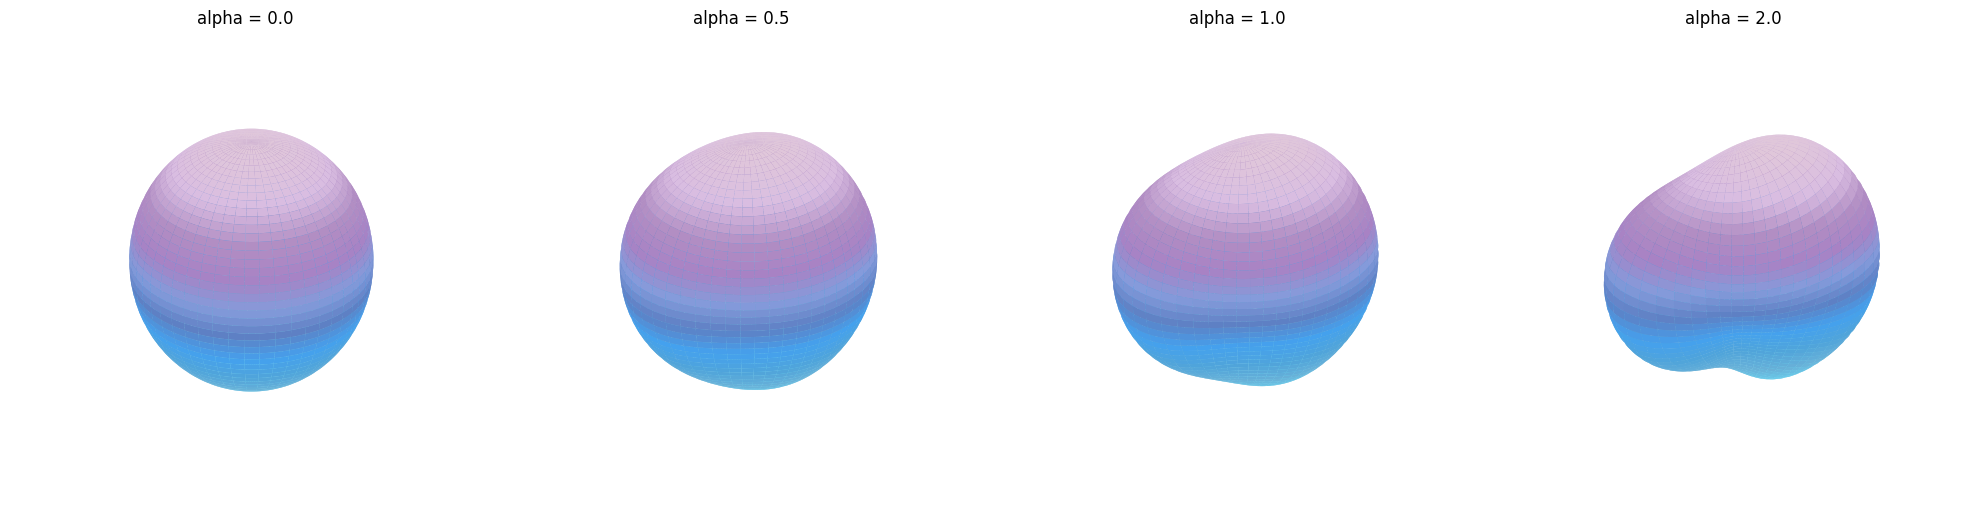

In [ ]:
## støj på vMF fordelingen!

# ---------- base sphere grid ----------
def sphere_grid(n_theta=100, n_phi=200):
    theta = np.linspace(0, np.pi, n_theta)
    phi = np.linspace(0, 2*np.pi, n_phi)
    theta, phi = np.meshgrid(theta, phi)

    x = np.sin(theta)*np.cos(phi)
    y = np.sin(theta)*np.sin(phi)
    z = np.cos(theta)

    return x, y, z


# ---------- smooth deformation function ----------
def deformation_function(x, y, z):
    # Smooth but asymmetric bump
    return 0.3*x*y + 0.2*z + 0.1*np.sin(3*x)*np.cos(2*y)


# ---------- apply deformation ----------
def deform_sphere(x, y, z, alpha):
    g = deformation_function(x, y, z)
    r = 1 + alpha * g
    return r*x, r*y, r*z


# ---------- plot ----------
def plot_deformed_spheres(alphas):
    fig = plt.figure(figsize=(5*len(alphas), 5))

    for i, alpha in enumerate(alphas):
        ax = fig.add_subplot(1, len(alphas), i+1, projection='3d')

        x, y, z = sphere_grid()
        xd, yd, zd = deform_sphere(x, y, z, alpha)

        ax.plot_surface(xd, yd, zd, cmap=blue_pink, linewidth=0, antialiased=True)
        ax.set_title(f"alpha = {alpha}")
        ax.set_box_aspect([1,1,1])
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()


# ---------- run ----------
plot_deformed_spheres([0.0, 0.5, 1.0, 2.0])

Hypotese: Bliver alignment lettere når (distributionen) manifolden mister rotationssymmetri?

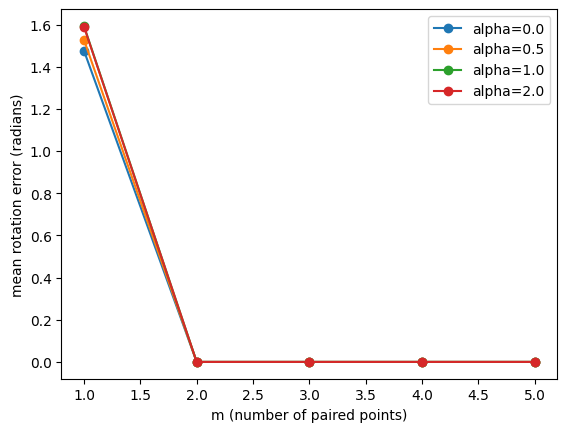

In [ ]:
# sample for den oprindelige 2-sphere
# map via deformation to get samples for deformed sphere
# (aka pushforward method)


# ---------- utils ----------
def random_rotation_so3(rng: np.random.Generator) -> np.ndarray:
    A = rng.normal(size=(3, 3))
    Q, _ = np.linalg.qr(A)
    if np.linalg.det(Q) < 0:
        Q[:, 0] *= -1
    return Q

def apply_rotation_rows(X: np.ndarray, R: np.ndarray) -> np.ndarray:
    return X @ R.T

def rotation_angle(R_hat: np.ndarray, R_true: np.ndarray) -> float:
    M = R_hat @ R_true.T
    val = (np.trace(M) - 1.0) / 2.0
    val = np.clip(val, -1.0, 1.0)
    return float(np.arccos(val))

# ---------- deformation ----------
def deformation_function(x, y, z):
    return 0.3*x*y + 0.2*z + 0.1*np.sin(3*x)*np.cos(2*y)

def deform_points(U: np.ndarray, alpha: float) -> np.ndarray:
    x, y, z = U[:, 0], U[:, 1], U[:, 2]
    g = deformation_function(x, y, z)
    r = 1.0 + alpha * g
    return r[:, None] * U

# ---------- experiment config ----------
@dataclass(frozen=True)
class ExperimentConfig:
    n_pairs: int = 200
    trials: int = 100
    ms: Tuple[int, ...] = (1, 2, 3, 4, 5)
    alphas: Tuple[float, ...] = (0.0, 0.25, 0.5, 1.0, 2.0)
    seed: int = 0

# ---------- main experiment ----------
def run_symmetry_breaking_experiment(
    vmf_source,  # vMF(mu,kappa) sampler on S^2
    estimate_rotation_fn,  # estimate_rotation(X,Y) -> R_hat
    config: ExperimentConfig,
) -> List[Dict[str, Any]]:

    rng0 = np.random.default_rng(config.seed)
    results: List[Dict[str, Any]] = []

    for alpha in config.alphas:
        for m in config.ms:
            rot_errors = []

            for _ in range(config.trials):
                rng = np.random.default_rng(rng0.integers(0, 2**32 - 1))

                # ground truth rotation
                R_true = random_rotation_so3(rng)

                # sample on sphere, then pushforward to deformed manifold
                U = vmf_source.sample(config.n_pairs, rng=rng)   # (n,3), ||u||=1
                X = deform_points(U, alpha)                      # (n,3), deformed

                # rotate (no extra noise!)
                Y = apply_rotation_rows(X, R_true)

                # estimate using first m paired points
                R_hat = estimate_rotation_fn(X[:m], Y[:m])

                # record rotation error
                rot_errors.append(rotation_angle(R_hat, R_true))

            results.append({
                "alpha": alpha,
                "m": m,
                "rot_err_mean": float(np.mean(rot_errors)),
                "rot_err_std": float(np.std(rot_errors)),
            })

    return results

# ---------- optional: quick plotting helper ----------
def plot_results(results: List[Dict[str, Any]]):
    import pandas as pd
    import matplotlib.pyplot as plt

    df = pd.DataFrame(results).sort_values(["alpha", "m"])
    for alpha, sub in df.groupby("alpha"):
        plt.plot(sub["m"], sub["rot_err_mean"], marker="o", label=f"alpha={alpha}")
    plt.xlabel("m (number of paired points)")
    plt.ylabel("mean rotation error (radians)")
    plt.legend()
    plt.show()

# ---------- usage ----------
vmf = VMF(mu, kappa_data)
config = ExperimentConfig(n_pairs=200, trials=200, ms=(1,2,3,4,5), alphas=(0.0,0.5,1.0,2.0), seed=42)
results = run_symmetry_breaking_experiment(vmf, estimate_rotation, config)
plot_results(results)

ok so this only test how many exact vector correspondences determine a rotation.

no noise here actually, just deformation of sphere.

#### No pairs - alpha deformed sphers

In [ ]:
import numpy as np
from scipy.spatial import cKDTree

# ---------- ICP (rigid rotation only) ----------
def icp_rotation_only(X, Y, max_iter=50, tol=1e-6):
    R = np.eye(3)

    for _ in range(max_iter):

        # Rotate source
        X_rot = X @ R.T

        # Nearest neighbor matching
        tree = cKDTree(Y)
        _, idx = tree.query(X_rot)
        Y_matched = Y[idx]

        H = X_rot.T @ Y_matched
        U, _, Vt = np.linalg.svd(H)
        R_update = Vt.T @ U.T

        if np.linalg.det(R_update) < 0:
            Vt[-1, :] *= -1
            R_update = Vt.T @ U.T

        R = R_update @ R

        # Convergence check
        if np.linalg.norm(R_update - np.eye(3)) < tol:
            break

    return R

In [ ]:
def run_unpaired_experiment(
    vmf_source,
    estimate_rotation_fn,   
    alphas=(0.0, 0.5, 1.0),
    n_points=500,
    trials=20,
    seed=0
):

    rng0 = np.random.default_rng(seed)
    results = []

    for alpha in alphas:
        errors = []

        for _ in range(trials):

            rng = np.random.default_rng(rng0.integers(0, 2**32 - 1))

            R_true = random_rotation_so3(rng)

            # Sample sphere
            U = vmf_source.sample(n_points, rng=rng)

            # Pushforward deformation
            X = deform_points(U, alpha)

            # Rotate and shuffle (remove pairing)
            Y = apply_rotation_rows(X, R_true)
            rng.shuffle(Y)

            # Estimate via ICP
            R_hat = icp_rotation_only(X, Y)

            errors.append(rotation_angle(R_hat, R_true))

        results.append({
            "alpha": alpha,
            "mean_rot_error": np.mean(errors),
            "std_rot_error": np.std(errors),
        })

    return results

def plot_unpaired_results(results):
    df = pd.DataFrame(results).sort_values("alpha")

    plt.figure(figsize=(6,4))
    plt.errorbar(
        df["alpha"],
        df["mean_rot_error"],
        yerr=df["std_rot_error"],
        marker="o",
        capsize=4
    )

    plt.xlabel("alpha (deformation strength)")
    plt.ylabel("mean rotation error")
    plt.title("Unpaired alignment error vs deformation")
    plt.grid(True)
    plt.show()

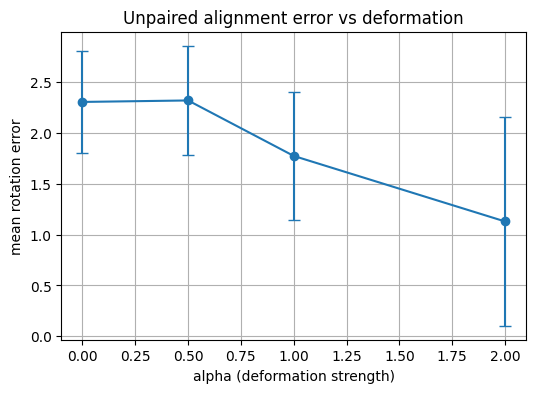

In [53]:
results = run_unpaired_experiment(
    vmf_source=vmf,
    estimate_rotation_fn=icp_rotation_only,
    alphas=(0.0, 0.5, 1.0, 2.0),
    n_points=500,
    trials=30
)

plot_unpaired_results(results)

#### PCA example